# **Eventos Adversos en medicamentos de la FDA**

https://www.kaggle.com/datasets/mdmahfuzsumon/hidden-drug-risks-revealed?resource=download

Csv utilizado:

 FDA Drug Adverse Events Dataset Q4-2025-P33.csv

Diccionario de datos

report_id Identificador único para cada informe de evento adverso

country País donde se envió el informe

occur_country País donde ocurrió el evento adverso

report_type Tipo de informe (p. ej., espontáneo, bibliográfico)

serious Indica si el caso es grave (1 = Sí, 0 = No)

death Indica si el evento resultó en la muerte

life_threatening Indica si el evento fue potencialmente mortal

hospitalization Indica si hubo hospitalización

disabling Indica si se produjo alguna discapacidad

receive_date Fecha de recepción del informe (AAAAMMDD)

age Edad del paciente

age_unit Unidad de edad (p. ej., años, meses)

gender Sexo del paciente (1 = Masculino, 2 = Femenino)

weight Peso del paciente (si está disponible)

drug Nombre del medicamento involucrado

reaction Descripción de la reacción adversa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Mineria de Datos/Evaluacion 1/FDA Drug Adverse Events Dataset Q4-2025-P33.csv')
display.max_columns = None
display.max_rows = 9999


# **Fase 1: Entendiendo el negocio y explorando datos**

Este conjunto de datos contiene informes de eventos adversos recolectados por la FDA. Lo elegimos porque presenta una buena mezcla de variables categóricas (país, medicamento, reacción) y numéricas (edad, peso). Es ideal para la continuidad del semestre ya que permite predecir la gravedad de un caso (Clasificación) o analizar tendencias de dosis y edad (Regresión), cumpliendo con el requisito de ser un dataset amplio y complejo.

In [2]:
df.head(5)

,report_id,country,occur_country,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight,drug,reaction
0,26016170,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,42.0,801.0,1.0,NaN,DUPIXENT,abdominal pain
1,26017452,NP,NP,1,1.0,1.0,2.0,1.0,2.0,20251110,51.0,801.0,1.0,NaN,METHOTREXATE,toxicity to various agents
2,26017586,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,NaN,NaN,2.0,NaN,PEPCID COMPLETE,exposure during pregnancy
3,26018910,SG,SG,1,1.0,2.0,2.0,2.0,2.0,20251110,62.0,801.0,2.0,NaN,PACLITAXEL,drug ineffective
4,26018949,EU,EU,3,1.0,2.0,2.0,2.0,2.0,20251110,NaN,NaN,NaN,NaN,DULOXETINE,drug interaction


In [3]:
#Valores nulos y tipos de datos

print("\nInformación de columnas:")
df.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1287 entries, 0 to 1286
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   report_id         1287 non-null   int64  
 1   country           1287 non-null   object 
 2   occur_country     1208 non-null   object 
 3   report_type       1287 non-null   int64  
 4   serious           1267 non-null   float64
 5   death             1233 non-null   float64
 6   life_threatening  1230 non-null   float64
 7   hospitalization   1242 non-null   float64
 8   disabling         1231 non-null   float64
 9   receive_date      1287 non-null   int64  
 10  age               880 non-null    float64
 11  age_unit          881 non-null    float64
 12  gender            1072 non-null   float64
 13  weight            295 non-null    float64
 14  drug              1287 non-null   object 
 15  reaction          1287 non-null   object 
dtypes: float64(9), i

In [4]:
print("\nValores nulos:")
print(df.isna().sum())


Valores nulos:
report_id             0
country               0
occur_country        79
report_type           0
serious              20
death                54
life_threatening     57
hospitalization      45
disabling            56
receive_date          0
age                 407
age_unit            406
gender              215
weight              992
drug                  0
reaction              0
dtype: int64


In [5]:
#Contenido del dataset
print(df.shape) #hacer graficos

(1287, 16)


Podemos ver que el dataset tiene mas de 900 nules en una fila tan importante como el peso por ende buscaremos la mejor forma de imputacion posible para tratar con esos nulos

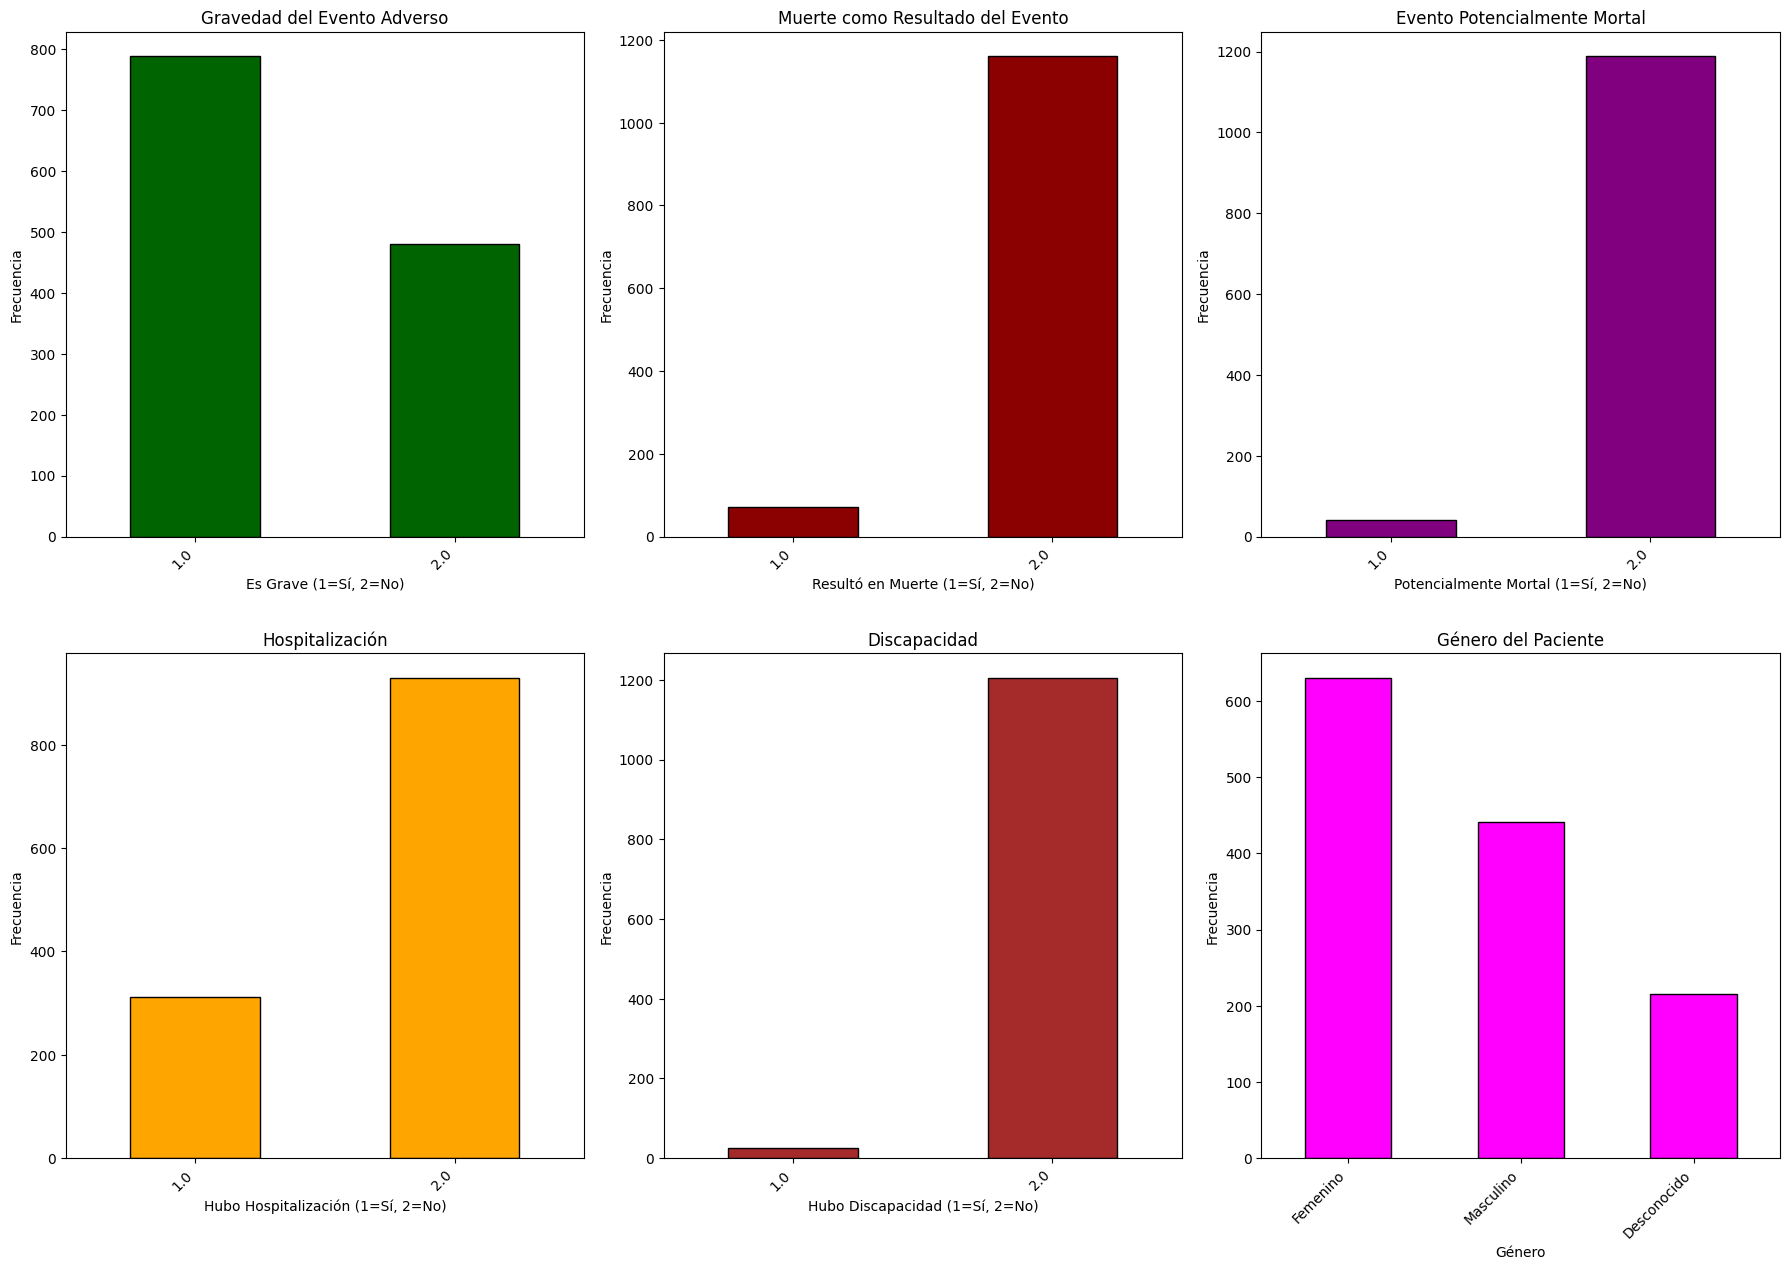

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# De los datos que no son nulos haremos un analisis preeliminar de variables categoricas

# Lista de columnas categóricas a graficar
categorical_cols = [
    ('serious', 'Gravedad del Evento Adverso', 'Es Grave (1=Sí, 2=No)', 'darkgreen'),
    ('death', 'Muerte como Resultado del Evento', 'Resultó en Muerte (1=Sí, 2=No)', 'darkred'),
    ('life_threatening', 'Evento Potencialmente Mortal', 'Potencialmente Mortal (1=Sí, 2=No)', 'purple'),
    ('hospitalization', 'Hospitalización', 'Hubo Hospitalización (1=Sí, 2=No)', 'orange'),
    ('disabling', 'Discapacidad', 'Hubo Discapacidad (1=Sí, 2=No)', 'brown'),
    ('gender', 'Género del Paciente', 'Género', 'magenta')
]

# Crear la figura y la cuadrícula de subplots (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 18)) # Ajustar a 3x3 y aumentar figsize
axes = axes.flatten() # Aplanar el array de axes para fácil iteración

for i, (col, title, xlabel, color) in enumerate(categorical_cols):
    ax = axes[i]

    if col == 'gender':
        gender_counts = df['gender'].fillna('Desconocido').map({1.0: 'Masculino', 2.0: 'Femenino', 'Desconocido': 'Desconocido'}).value_counts()
        gender_counts.plot(kind='bar', color=color, edgecolor='black', ax=ax)
    else:
        df[col].value_counts().sort_index().plot(kind='bar', color=color, edgecolor='black', ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    # If horizontal alignment is still needed, it should be set on the tick labels explicitly:
    plt.setp(ax.get_xticklabels(), ha='right', rotation=45)

# Ocultar los ejes de los subplots vacíos
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

De esta forma podemos ver la distribucion de algunas categoricas one hot, podemos fijarnos que el dataset esas variables "one hot" son de 1 y 2 y no 0 y 1, lo que puede influenciar a futuro para clasificaciones binarias

In [7]:
df['country'].unique()

array(['US', 'NP', 'SG', 'EU', 'CA', 'JP', 'CN', 'KR', 'GB', 'PR', 'MX',
       'AU', 'BR', 'ZA', 'IN', 'ID', 'CH', 'PH', 'RU', 'CO', 'DZ', 'TH',
       'TW', 'NZ', 'AR', 'AE', 'NG', 'VE', 'EG', 'BA', 'VN', 'IL', 'CR',
       'CL'], dtype=object)

In [8]:
df['drug'].unique()

array(['DUPIXENT', 'METHOTREXATE', 'PEPCID COMPLETE', 'PACLITAXEL',
       'DULOXETINE', 'DOCETAXEL', 'POLYETHYLENE GLYCOL 3350',
       'VEDOLIZUMAB', 'BEVACIZUMAB', 'SKYRIZI', 'ABIRATERONE ACETATE',
       'WEGOVY', 'NEULASTA', 'REMODULIN', 'LETROZOLE', 'MINOCYCLINE',
       'DEXAMETHASONE', 'RITUXIMAB', 'AXICABTAGENE CILOLEUCEL',
       'FIRDAPSE', 'TRULICITY', 'METHOTREXATE SODIUM', 'ACETAMINOPHEN',
       'VONJO', 'RIVAROXABAN', 'VOLTAREN', 'PLUVICTO', 'NUPLAZID',
       'TISLELIZUMAB', 'ISONIAZID', 'LENALIDOMIDE', 'CARBOPLATIN',
       'CREON', 'CYCLOSPORINE', 'HUMAN IMMUNOGLOBULIN G', 'LOSARTAN',
       'SIROLIMUS', 'AYVAKIT', 'CORTICOTROPIN', 'SPRAVATO',
       'TRELEGY ELLIPTA', 'GEMTESA', 'ORGOVYX', 'OPDIVO', 'OCREVUS',
       'BUPRENORPHINE', 'TORIPALIMAB', 'MIRTAZAPINE', 'ESOMEPRAZOLE',
       'VENCLEXTA', 'XGEVA', 'BENRALIZUMAB', 'CITALOPRAM', 'ORENCIA',
       'TIGECYCLINE', 'FINASTERIDE', 'IXAZOMIB', 'IBUPROFEN',
       'MYCOPHENOLATE MOFETIL', 'RISPERIDONE', 'AZATHIOPRI

Tenemos demasiadas categorias aqui lo mejor para aplicar un onehot pueda ser por clase o binaria

In [9]:
#Variables Numericas

df.describe().round(2)

,report_id,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight
count,1287.00,1287.00,1267.00,1233.00,1230.00,1242.00,1231.00,1287.00,880.00,881.00,1072.00,295.00
mean,25423623.71,1.21,1.38,1.94,1.97,1.75,1.98,20247726.19,52.50,801.00,1.59,76.85
std,1519859.27,0.44,0.49,0.23,0.18,0.43,0.14,9546.39,21.94,0.16,0.49,27.80
min,14520544.00,1.00,1.00,1.00,1.00,1.00,1.00,20180212.00,0.00,800.00,1.00,1.88
25%,25652722.50,1.00,1.00,2.00,2.00,1.00,2.00,20250807.00,36.00,801.00,1.00,59.04
50%,25981881.00,1.00,1.00,2.00,2.00,2.00,2.00,20251031.00,57.00,801.00,2.00,75.00
75%,26086189.50,1.00,2.00,2.00,2.00,2.00,2.00,20251125.00,70.00,801.00,2.00,90.70
max,26216860.00,3.00,2.00,2.00,2.00,2.00,2.00,20251231.00,100.00,804.00,2.00,220.00


## **Trabajo con nulos**

Debido a que la mayoria de nulos se centralizan en las variables numericas estos estidisticos se encuentran sesgados, se realizara un trabajo a los nulos para ver la correlacion

Primero imputamos las variables categóricas y binarias con menos nulos. Estas servirán como predictores para la edad y el peso.

serious, death, life_threatening, hospitalization, disabling: Son los resultados del evento. Siendo datos de la FDA, la Moda es el camino más seguro para no inventar gravedades que no existen.

gender (215 nulos): Al no ser mas de 50% de nulos, la moda es aceptable, pero lo ideal es imputar antes de ir a por el peso, ya que el peso depende mucho del género.

occur_country (79 nulos): Técnica de "Negocio": Si el país de ocurrencia es nulo, lo más probable es que sea el mismo que el país de reporte (country).

In [10]:
# Creamos df2 como una copia profunda para no afectar el dataset original
df2 = df.copy()
print("Copia df2 creada. Listos para iniciar la limpieza.")

Copia df2 creada. Listos para iniciar la limpieza.


In [11]:
# Definimos las columnas que imputaremos por el valor más frecuente (Moda)
cols_binarias = ['serious', 'death', 'life_threatening', 'hospitalization', 'disabling', 'gender', 'age_unit']

for col in cols_binarias:

    df2[col] = df2[col].fillna(df2[col].mode()[0])

# 2. Lógica de negocio para el país de ocurrencia
# Si no se especifica, asumimos que es el mismo país que reporta
df2['occur_country'] = df2['occur_country'].fillna(df2['country'])

print("Fase 1 completada: Variables categóricas y lógicas imputadas.")
df2[['serious', 'death', 'life_threatening', 'hospitalization', 'disabling', 'gender', 'age_unit']].isnull().sum()

Fase 1 completada: Variables categóricas y lógicas imputadas.


,0
serious,0
death,0
life_threatening,0
hospitalization,0
disabling,0
gender,0
age_unit,0


Age_unit no logramos comprender esta variable por lo tanto en la seleccion de variables para el modelo sera eliminada esta variable

In [12]:
# Seleccionamos las columnas numéricas que servirán de base para la predicción
# Incluimos las que acabamos de limpiar para que ayuden al modelo
cols_modelo = ['age', 'weight', 'gender', 'serious', 'hospitalization', 'death']

# IterativeImputer usa regresión por defecto
imputer = IterativeImputer(random_state=42, max_iter=10)

# Aplicamos la transformación solo a las columnas de interés
df2[cols_modelo] = imputer.fit_transform(df2[cols_modelo])

print("Fase 2 completada: Edad y Peso imputados mediante regresión.")

Fase 2 completada: Edad y Peso imputados mediante regresión.


In [13]:
#Redondeamos los valores para no tener numeros inconclusos en edad y
#no tener muchos decimales en los pesos

df2['weight'] = df2['weight'].round(2)
df2['age'] = df2['age'].round(0)
df2.head(10)

,report_id,country,occur_country,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight,drug,reaction
0,26016170,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,42.0,801.0,1.0,71.84,DUPIXENT,abdominal pain
1,26017452,NP,NP,1,1.0,1.0,2.0,1.0,2.0,20251110,51.0,801.0,1.0,75.03,METHOTREXATE,toxicity to various agents
2,26017586,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,49.0,801.0,2.0,74.40,PEPCID COMPLETE,exposure during pregnancy
3,26018910,SG,SG,1,1.0,2.0,2.0,2.0,2.0,20251110,62.0,801.0,2.0,78.91,PACLITAXEL,drug ineffective
4,26018949,EU,EU,3,1.0,2.0,2.0,2.0,2.0,20251110,54.0,801.0,2.0,75.86,DULOXETINE,drug interaction
5,26019625,US,US,1,1.0,2.0,2.0,2.0,2.0,20251110,67.0,801.0,1.0,80.79,DOCETAXEL,osteoporosis
6,26019988,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,49.0,801.0,2.0,74.40,POLYETHYLENE GLYCOL 3350,incorrect product administration duration
7,25942883,CA,CA,2,1.0,2.0,2.0,2.0,2.0,20251021,46.0,801.0,1.0,73.23,VEDOLIZUMAB,colitis ulcerative
8,25942964,JP,JP,1,1.0,1.0,2.0,2.0,2.0,20251021,78.0,801.0,1.0,84.76,BEVACIZUMAB,vascular stent thrombosis
9,25943989,US,US,1,2.0,2.0,2.0,2.0,2.0,20251021,49.0,801.0,2.0,74.40,SKYRIZI,swelling of eyelid


# **Estadisticos basicos y distribucion de los valores**

In [14]:
df2.describe().round(2)

,report_id,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight
count,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00
mean,25423623.71,1.21,1.37,1.94,1.97,1.76,1.98,20247726.19,52.25,801.00,1.66,75.45
std,1519859.27,0.44,0.48,0.23,0.18,0.43,0.14,9546.39,18.48,0.13,0.47,14.45
min,14520544.00,1.00,1.00,1.00,1.00,1.00,1.00,20180212.00,0.00,800.00,1.00,1.88
25%,25652722.50,1.00,1.00,2.00,2.00,2.00,2.00,20250807.00,45.00,801.00,1.00,70.26
50%,25981881.00,1.00,1.00,2.00,2.00,2.00,2.00,20251031.00,54.00,801.00,2.00,75.75
75%,26086189.50,1.00,2.00,2.00,2.00,2.00,2.00,20251125.00,65.00,801.00,2.00,80.07
max,26216860.00,3.00,2.00,2.00,2.00,2.00,2.00,20251231.00,102.00,804.00,2.00,220.00


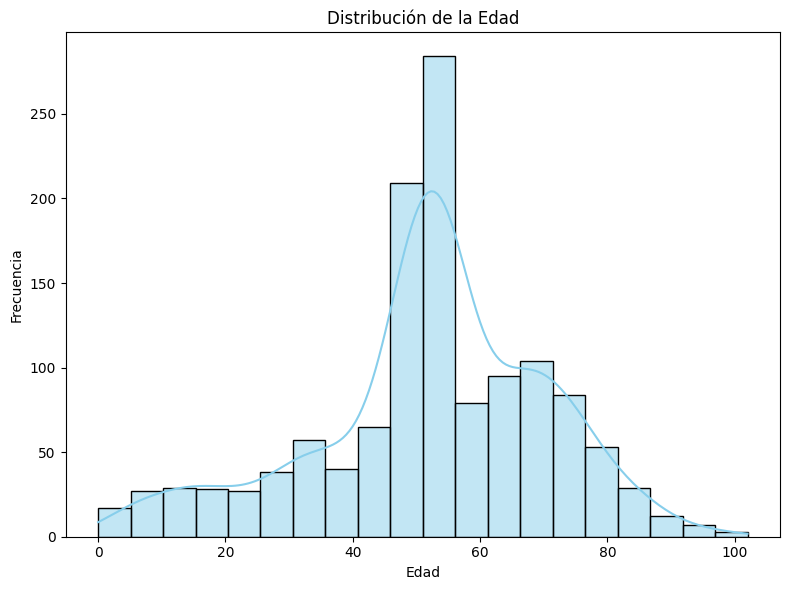

In [15]:
# Histograma para la edad
plt.figure(figsize=(8, 6))
sns.histplot(df2['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

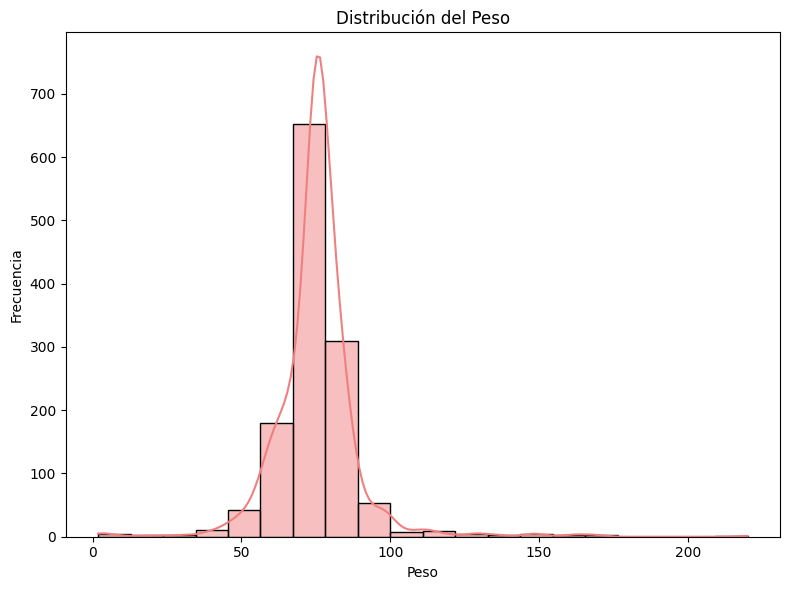

In [16]:
# Histograma para el peso
plt.figure(figsize=(8, 6))
sns.histplot(df2['weight'], bins=20, kde=True, color='lightcoral')
plt.title('Distribución del Peso')
plt.xlabel('Peso')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Necesitamos filtrar datos para ver si hay valores atipicos, pesos muy altos para edades bajas o edad baja con pesos muy altos

In [17]:
# Filtro para detectar edades > 2 años con pesos imposibles (< 10kg)
incoherentes = df2[(df2['age'] >= 2) & (df2['weight'] < 10)]

print(f"Se encontraron {len(incoherentes)} casos imposibles:")
display(incoherentes[['report_id', 'age', 'weight', 'drug', 'reaction']])

Se encontraron 4 casos imposibles:


,report_id,age,weight,drug,reaction
90,25974459,11.0,1.88,METOPROLOL,bradycardia neonatal
365,19806455,12.0,8.30,SABRIL,retinal degeneration
456,26049965,5.0,3.90,SUGAMMADEX SODIUM,anaphylactic reaction
1286,25237383,10.0,2.49,GENTAMICIN,neonatal respiratory distress syndrome


In [18]:
# Filtro: Niños menores de 10 años con pesos mayores a 30kg (Incoherencia por arriba)
pesos_altos_ninos = df2[(df2['age'] <= 12) & (df2['weight'] > 40)]

print(f"Se detectaron {len(pesos_altos_ninos)} niños con pesos exageradamente altos.")
display(pesos_altos_ninos[['age', 'weight', 'drug', 'reaction']])

Se detectaron 41 niños con pesos exageradamente altos.


,age,weight,drug,reaction
19,4.0,58.15,MINOCYCLINE,therapy partial responder
33,9.0,59.87,DUPIXENT,breast mass
115,8.0,59.45,MYCOPHENOLATE MOFETIL,lymphadenitis
128,4.0,58.15,DUPIXENT,dry skin
142,8.0,59.53,DARATUMUMAB,infection
179,8.0,51.50,TRIAMCINOLONE ACETONIDE,ascites
215,9.0,59.89,CABOMETYX,immune-mediated hepatic disorder
216,2.0,57.43,DUPIXENT,rash macular
292,9.0,59.81,DUPIXENT,suicidal ideation
355,4.0,58.09,NITROGLYCERIN,drug ineffective


Vamos a eliminar estos "outliers"

In [19]:
# Definimos la máscara de limpieza basada en tus filtros
outliers = (
    ((df2['age'] <= 12) & (df2['weight'] > 40)) |  # Niños muy pesados (error de imputación)
    ((df2['age'] >= 5) & (df2['weight'] < 10))     # Niños grandes con peso de recién nacido
)


total_borrados = len(df2[outliers])

#Limpiamos df2
df2 = df2.drop(df2[outliers].index)

print(f"¡Limpieza ejecutada! Se eliminaron {total_borrados} registros inconsistentes.")
print("Filas restantes en el dataset: ", df2.shape)

¡Limpieza ejecutada! Se eliminaron 45 registros inconsistentes.
Filas restantes en el dataset:  (1242, 16)


In [20]:
# Comprobamos que el peso máximo para niños menores de 5 años sea razonable ahora
print("Máximo peso en menores de 5 años tras la limpieza:")
print(df2[df2['age'] < 5]['weight'].max())

Máximo peso en menores de 5 años tras la limpieza:
16.4


# **Aplicando One-hot**

Como hay varias columnas que son categoricas y tienes demasiados valores como la columna "drug" y "reaction" haremos uso de binary encoding para no tener demasiadas filas

In [21]:
!pip install category_encoders

import category_encoders as ce

# **Columna drug**

In [22]:
df2['drug_name'] = df2['drug'] #Creamos una copia por que la columna se va a borrar


encoder_drug = ce.BinaryEncoder(cols=['drug'])

# 2. Transformamos df2
df2 = encoder_drug.fit_transform(df2)

print("Transformación completada con éxito")
# Verificamos que tenemos tanto los bits como el nombre
display(df2[['drug_name', 'drug_0', 'drug_1', 'drug_8']].head())

Transformación completada con éxito.


,drug_name,drug_0,drug_1,drug_8
0,DUPIXENT,0,0,1
1,METHOTREXATE,0,0,0
2,PEPCID COMPLETE,0,0,1
3,PACLITAXEL,0,0,0
4,DULOXETINE,0,0,1


In [26]:
#Diccionario de binary encoder

columnas_binarias = [c for c in df2.columns if 'drug_' in c and c != 'drug_name']

# Agrupamos por nombre para tener una fila por cada farmaco con su código
diccionario_drogas = df2[['drug_name'] + columnas_binarias].drop_duplicates()

# Lo ordenamos por nombre para que sea fácil de buscar
diccionario_drogas = diccionario_drogas.sort_values('drug_name').reset_index(drop=True)

# Guardamos este diccionario en un CSV aparte
diccionario_drogas.to_csv('diccionario_mapeo_farmacos.csv', index=False)

print("¡Diccionario creado con éxito!")
print(f"Total de drogas mapeadas: {len(diccionario_drogas)}")
display(diccionario_drogas.head(10))

¡Diccionario creado con éxito!
Total de drogas mapeadas: 459


,drug_name,drug_0,drug_1,drug_2,drug_3,drug_4,drug_5,drug_6,drug_7,drug_8
0,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,1,1,1,0,0,0,0,0,1
1,ABACAVIR SULFATE\LAMIVUDINE,0,1,1,0,0,1,1,1,0
2,ABILIFY MAINTENA,0,1,0,0,0,0,0,1,1
3,ABIRATERONE ACETATE,0,0,0,0,0,1,0,1,1
4,ABRILADA,1,0,0,1,0,0,1,1,0
5,ACCRUFER,0,0,1,1,1,1,1,0,1
6,ACETAMINOPHEN,0,0,0,0,1,0,1,1,0
7,ACOLTREMON,0,1,0,0,0,1,0,1,0
8,ACTEMRA,1,0,0,0,1,0,1,0,0
9,ADALIMUMAB,0,1,1,1,1,0,1,1,0


# **Columna: Reaction**

In [27]:
# 1. Guardamos la copia para nosotros
df2['reaction_nombre'] = df2['reaction']

# 2. Aplicamos Binary Encoding
# Nota: Esto creará columnas del tipo reaction_0, reaction_1... reaction_9
encoder_rx = ce.BinaryEncoder(cols=['reaction'])
df2 = encoder_rx.fit_transform(df2)

print("Codificación de reacciones completada.")

Codificación de reacciones completada.


In [28]:
# Filtramos las nuevas columnas binarias de reacción
cols_rx_bin = [c for c in df2.columns if 'reaction_' in c and c != 'reaction_nombre']

# Creamos el mapa de traducción
diccionario_rx = df2[['reaction_nombre'] + cols_rx_bin].drop_duplicates()
diccionario_rx = diccionario_rx.sort_values('reaction_nombre').reset_index(drop=True)

# Guardamos el respaldo
diccionario_rx.to_csv('diccionario_mapeo_reacciones.csv', index=False)

print(f"Diccionario de reacciones creado con {len(diccionario_rx)} términos.")
display(diccionario_rx.head(5))

Diccionario de reacciones creado con 625 términos.


,reaction_nombre,reaction_0,reaction_1,reaction_2,reaction_3,reaction_4,reaction_5,reaction_6,reaction_7,reaction_8,reaction_9
0,abdominal discomfort,0,0,1,1,1,0,1,0,1,0
1,abdominal operation,1,0,0,0,1,1,0,1,0,1
2,abdominal pain,0,0,0,0,0,0,0,0,0,1
3,abdominal pain upper,0,1,0,0,0,1,1,0,0,1
4,abnormal sensation in eye,0,0,1,0,1,1,0,0,0,0


In [30]:
df2.shape

(1242, 35)